# Importação de Pacotes

In [1]:
#leitura da base de dados
import pandas as pd
from pathlib import Path

#modelo preditivo escolhido
from sklearn.ensemble import HistGradientBoostingClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer

In [2]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(
        ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
    )

    print(f"""
      Acurária: {round(acuracia,3)};
      Revocação: {round(recall,3)};
      F1: {round(F1,3)};
      Roc_Auc: {round(roc_auc,3)}""")

## Leitura DataFrame

In [3]:
direcao = Path("../..") / "data"
caminho = direcao / "enatjus.csv"

df = pd.read_csv(caminho)

In [4]:
df.columns

Index(['medicamento', 'cid', 'origem_tratada', 'selDefensoriaPublica',
       'selStaGenero', 'selEsfera', 'selIndicacaoConformidade',
       'selPrevistoProtocolo', 'selRegistroAnvisa', 'selDisponivelSus',
       'selOncologico', 'selExisteBiossimilar', 'conitec', 'y'],
      dtype='object')

## Escolha do Modelo e Parâmetros

In [5]:
modelo= HistGradientBoostingClassifier()

In [6]:
parametros = {
    "modelo__learning_rate": [0.1],
    "modelo__max_depth": [10],
    "modelo__max_leaf_nodes": [31],
    "modelo__min_samples_leaf": [20],
    "modelo__l2_regularization": [0.0],
    "modelo__max_bins": [255],
}

# Aplicação de Pipelines

In [7]:
lista_X = ['medicamento', 'origem_tratada', 'selDefensoriaPublica',
       'selStaGenero', 'selEsfera', 'selIndicacaoConformidade',
       'selPrevistoProtocolo', 'selRegistroAnvisa', 'selDisponivelSus',
       'selOncologico', 'selExisteBiossimilar', 'conitec']


X = df[lista_X]

y = df["y"]


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#função para pipeline
def subst_cat_nan(coluna):
    coluna = pd.DataFrame(coluna).copy()
    coluna = coluna.replace("NÃO_PREENCHIDO", np.nan)
    return coluna.to_numpy()


#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('subst_cat_nan', FunctionTransformer(subst_cat_nan)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_prep, lista_X)
    ])


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=5
)


### Fitting

In [8]:

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__l2_regularization': [0.0], 'modelo__learning_rate': [0.1], 'modelo__max_bins': [255], 'modelo__max_depth': [10], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


### Métricas


      Acurária: 0.783;
      Revocação: 0.661;
      F1: 0.675;
      Roc_Auc: 0.753


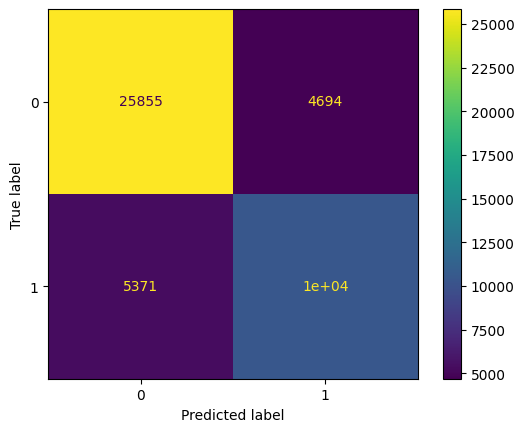

In [9]:
estimadores(searchCV_pipeline, X_test, y_test)

### **Testando mais Parâmetros**

In [10]:
parametros = {
    "modelo__learning_rate": [0.05, 0.1, 0.2],
    "modelo__max_depth": [10, 20, None],
    "modelo__max_leaf_nodes": [31, 63],
    "modelo__min_samples_leaf": [10, 20],
    "modelo__l2_regularization": [0.0, 0.1, 1.0],
    "modelo__max_bins": [255],
}

In [11]:
searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__l2_regularization': [0.0], 'modelo__learning_rate': [0.1], 'modelo__max_bins': [255], 'modelo__max_depth': [10], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.783;
      Revocação: 0.659;
      F1: 0.674;
      Roc_Auc: 0.753


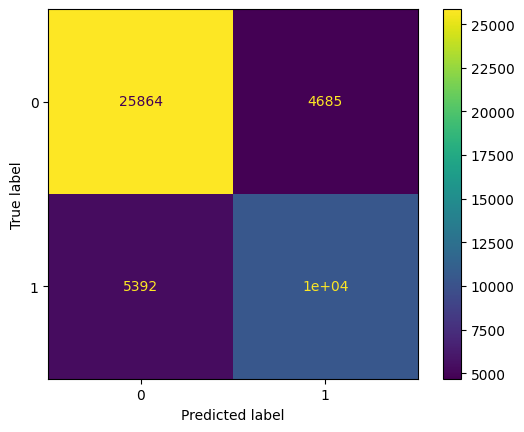

In [12]:
estimadores(searchCV_pipeline, X_test, y_test)

## **Extração de Amostras para Análise Qualitativa de Falsos Positivos e Negativos**

In [39]:
y_pred = searchCV_pipeline.predict(X_test)

resultados = X_test.copy()
resultados["y"] = y_test.values
resultados["y_pred"] = y_pred

falso_positivo = resultados[(resultados["y"] == 0) & (resultados["y_pred"] == 1)]
falso_negativo = resultados[(resultados["y"] == 1) & (resultados["y_pred"] == 0)]

amostra_fp = falso_positivo.sample(n=min(10, len(falso_positivo)), random_state=22)
amostra_fn= falso_negativo.sample(n=min(10, len(falso_negativo)), random_state=22)

### Análise Falso Positivo

In [14]:
len(falso_positivo)

4685

In [40]:
amostra_fp

,medicamento,origem_tratada,selDefensoriaPublica,selStaGenero,selEsfera,selIndicacaoConformidade,selPrevistoProtocolo,selRegistroAnvisa,selDisponivelSus,selOncologico,selExisteBiossimilar,conitec,y,y_pred
2699,ACETATO DE ABIRATERONA,Nacional,D,m,E,S,N,S,N,S,S,F,0,1
50052,DURVALUMABE,Nacional,D,m,F,S,N,S,N,S,N,Sem informação,0,1
49093,ABEMACICLIBE,Nacional,NÃO_PREENCHIDO,f,F,S,N,S,N,S,N,Sem informação,0,1
8141,NATALIZUMABE,Nacional,NÃO_PREENCHIDO,m,E,S,S,S,S,N,N,Sem informação,0,1
53728,TOSILATO DE SORAFENIBE,Nacional,NÃO_PREENCHIDO,f,F,S,N,S,N,S,N,Sem informação,0,1
119150,PEMBROLIZUMABE,Nacional,NÃO_PREENCHIDO,m,F,S,N,S,N,S,N,Sem informação,0,1
127539,AFLIBERCEPTE,Nacional,NÃO_PREENCHIDO,m,E,S,N,S,N,N,N,F,0,1
117457,DARATUMUMABE,Nacional,D,m,F,S,N,S,N,S,N,Sem informação,0,1
6475,RITUXIMABE,Nacional,NÃO_PREENCHIDO,f,E,S,N,S,S,N,N,Sem informação,0,1
76085,CARVEDILOL,RS/DMJ,NÃO_PREENCHIDO,f,E,S,S,S,S,N,S,Sem informação,0,1


In [16]:
def porcent(df, coluna):
    print(coluna)
    for i in df[coluna].unique():
        porcen = round(len(df[df[coluna] == i])/len(df), 2)*100
        print(f"{i} = {porcen}%")
    print()
        

In [17]:
colunas = falso_positivo.columns
colunas = list(falso_positivo.columns)
colunas.remove("medicamento")
colunas.remove("y_pred")
colunas.remove("y")

for e in colunas:
    porcent(falso_positivo, e)

origem_tratada
RJ = 3.0%
Nacional = 68.0%
RS/DMJ = 4.0%
PE = 1.0%
SP = 4.0%
RN = 1.0%
SC = 0.0%
PR = 1.0%
BA = 4.0%
PB = 1.0%
TelessaúdeRS-UFRGS = 1.0%
RR = 0.0%
TO = 0.0%
SE = 1.0%
DF = 3.0%
MS = 2.0%
CE = 0.0%
GO = 1.0%
PA = 0.0%
AC = 0.0%
MA = 1.0%
PR/CAMS = 0.0%
SP/HC = 0.0%
AL = 0.0%
PR/UEL = 0.0%
ES = 0.0%
MT = 0.0%
AM/SES = 0.0%
PI = 0.0%

selDefensoriaPublica
NÃO_PREENCHIDO = 70.0%
D = 27.0%
M = 2.0%

selStaGenero
m = 45.0%
f = 55.00000000000001%

selEsfera
E = 53.0%
F = 47.0%

selIndicacaoConformidade
S = 97.0%
N = 2.0%
X = 1.0%
B = 0.0%

selPrevistoProtocolo
N = 68.0%
S = 28.000000000000004%
X = 4.0%
B = 0.0%

selRegistroAnvisa
S = 99.0%
N = 1.0%

selDisponivelSus
N = 66.0%
S = 33.0%
X = 1.0%
B = 0.0%

selOncologico
N = 45.0%
S = 53.0%
X = 2.0%
B = 0.0%

selExisteBiossimilar
N = 78.0%
S = 22.0%

conitec
D = 11.0%
Sem informação = 50.0%
F = 39.0%



In [18]:
for e in colunas:
    porcent(df, e)

origem_tratada
Nacional = 60.0%
PR = 2.0%
RJ = 2.0%
AM/SEMSA = 0.0%
RS/DMJ = 6.0%
MT = 4.0%
SP = 7.000000000000001%
TelessaúdeRS-UFRGS = 3.0%
MA = 1.0%
PR/CAMS = 0.0%
SP/HC = 0.0%
DF = 2.0%
ES = 1.0%
BA = 2.0%
MS = 4.0%
AL = 0.0%
SE = 1.0%
PB = 0.0%
PI = 0.0%
RN = 1.0%
AC = 0.0%
RR = 0.0%
SC = 0.0%
GO = 1.0%
CE = 0.0%
PE = 1.0%
PA = 0.0%
AM/SES = 0.0%
PR/CHC-UFPR = 0.0%
TO = 0.0%
PR/UEL = 0.0%
AP = 0.0%
AM = 0.0%
RS = 0.0%

selDefensoriaPublica
NÃO_PREENCHIDO = 63.0%
D = 34.0%
M = 3.0%

selStaGenero
m = 44.0%
f = 56.00000000000001%
NÃO_PREENCHIDO = 0.0%

selEsfera
E = 73.0%
F = 27.0%

selIndicacaoConformidade
S = 86.0%
N = 10.0%
X = 3.0%
B = 0.0%
NÃO_PREENCHIDO = 0.0%

selPrevistoProtocolo
N = 79.0%
X = 4.0%
S = 17.0%
B = 0.0%

selRegistroAnvisa
S = 98.0%
N = 2.0%

selDisponivelSus
N = 75.0%
S = 23.0%
X = 1.0%
B = 1.0%

selOncologico
S = 23.0%
N = 76.0%
X = 1.0%
B = 0.0%

selExisteBiossimilar
N = 59.0%
S = 41.0%
NÃO_PREENCHIDO = 0.0%

conitec
F = 18.0%
Sem informação = 57.9999999999999

Tratando-se dos casos com falso negativos, não foi possível observar nenhum padrão muito claro apenas pela observação da amostra recolhida, visto que, pela grande verticalização da base de dados, a quantidade de total de falso negativos também foi muito grande. A partir disso, comparando a composição percentil do conjunto de casos falsos negativos com o total de casos na base de dados, foram observados três fatores com discrepâncias significativas: na coluna "selEsfera" houve uma sobre-representatividade de "F";  na coluna "selOncológico" houve uma sobre-representatividade de "S"; na coluna "selExisteBiossimilar" houve sub-representatividade de "S".

### Análise Falso Negativo

In [19]:
len(falso_negativo)

5392

In [20]:
amostra_fn

,medicamento,origem_tratada,selDefensoriaPublica,selStaGenero,selEsfera,selIndicacaoConformidade,selPrevistoProtocolo,selRegistroAnvisa,selDisponivelSus,selOncologico,selExisteBiossimilar,conitec,y,y_pred
129699,cesteamine,Nacional,D,m,F,N,N,N,N,N,N,Sem informação,1,0
143145,TETRAIDROCANABINOL + CANABIDIOL,Nacional,NÃO_PREENCHIDO,m,F,N,N,N,N,N,N,Sem informação,1,0
78947,ENOXAPARINA SÓDICA,Nacional,NÃO_PREENCHIDO,f,E,S,N,S,S,N,S,Sem informação,1,0
111375,CILOSTAZOL,RS/DMJ,D,m,E,S,N,S,N,N,S,Sem informação,1,0
100757,DENOSUMABE,RS/DMJ,D,m,E,S,N,S,N,N,N,D,1,0
40819,DAPAGLIFLOZINA,Nacional,NÃO_PREENCHIDO,m,E,S,N,S,S,N,S,F,1,0
119817,RISPERIDONA,Nacional,D,f,E,S,N,S,S,N,S,Sem informação,1,0
151824,NIVOLUMABE,Nacional,D,m,E,S,N,S,N,S,N,Sem informação,1,0
50016,OLANZAPINA,Nacional,NÃO_PREENCHIDO,m,F,N,N,S,S,N,S,Sem informação,1,0
48888,TOPIRAMATO,Nacional,D,m,E,S,N,S,N,N,N,Sem informação,1,0


In [21]:
for e in colunas:
    porcent(falso_negativo, e)

origem_tratada
Nacional = 61.0%
PR = 4.0%
MT = 2.0%
SP = 8.0%
RS/DMJ = 8.0%
MS = 3.0%
TelessaúdeRS-UFRGS = 2.0%
DF = 2.0%
RJ = 1.0%
PA = 0.0%
PE = 1.0%
SE = 2.0%
GO = 0.0%
MA = 1.0%
RR = 0.0%
CE = 0.0%
BA = 1.0%
PB = 0.0%
PI = 0.0%
RN = 1.0%
AL = 0.0%
SC = 1.0%
RS = 0.0%
ES = 1.0%
PR/UEL = 0.0%
AC = 0.0%
TO = 0.0%
PR/CAMS = 0.0%
SP/HC = 0.0%
AM/SES = 0.0%
AM/SEMSA = 0.0%
AP = 0.0%
PR/CHC-UFPR = 0.0%

selDefensoriaPublica
D = 33.0%
NÃO_PREENCHIDO = 63.0%
M = 4.0%

selStaGenero
m = 48.0%
f = 52.0%

selEsfera
E = 79.0%
F = 21.0%

selIndicacaoConformidade
S = 84.0%
N = 12.0%
X = 4.0%
B = 0.0%

selPrevistoProtocolo
N = 81.0%
X = 4.0%
S = 15.0%
B = 0.0%

selRegistroAnvisa
S = 97.0%
N = 3.0%

selDisponivelSus
N = 73.0%
S = 25.0%
X = 1.0%
B = 0.0%

selOncologico
S = 19.0%
N = 81.0%
X = 0.0%

selExisteBiossimilar
N = 59.0%
S = 41.0%
NÃO_PREENCHIDO = 0.0%

conitec
D = 25.0%
Sem informação = 66.0%
F = 9.0%



In [22]:
for e in colunas:
    porcent(df, e)

origem_tratada
Nacional = 60.0%
PR = 2.0%
RJ = 2.0%
AM/SEMSA = 0.0%
RS/DMJ = 6.0%
MT = 4.0%
SP = 7.000000000000001%
TelessaúdeRS-UFRGS = 3.0%
MA = 1.0%
PR/CAMS = 0.0%
SP/HC = 0.0%
DF = 2.0%
ES = 1.0%
BA = 2.0%
MS = 4.0%
AL = 0.0%
SE = 1.0%
PB = 0.0%
PI = 0.0%
RN = 1.0%
AC = 0.0%
RR = 0.0%
SC = 0.0%
GO = 1.0%
CE = 0.0%
PE = 1.0%
PA = 0.0%
AM/SES = 0.0%
PR/CHC-UFPR = 0.0%
TO = 0.0%
PR/UEL = 0.0%
AP = 0.0%
AM = 0.0%
RS = 0.0%

selDefensoriaPublica
NÃO_PREENCHIDO = 63.0%
D = 34.0%
M = 3.0%

selStaGenero
m = 44.0%
f = 56.00000000000001%
NÃO_PREENCHIDO = 0.0%

selEsfera
E = 73.0%
F = 27.0%

selIndicacaoConformidade
S = 86.0%
N = 10.0%
X = 3.0%
B = 0.0%
NÃO_PREENCHIDO = 0.0%

selPrevistoProtocolo
N = 79.0%
X = 4.0%
S = 17.0%
B = 0.0%

selRegistroAnvisa
S = 98.0%
N = 2.0%

selDisponivelSus
N = 75.0%
S = 23.0%
X = 1.0%
B = 1.0%

selOncologico
S = 23.0%
N = 76.0%
X = 1.0%
B = 0.0%

selExisteBiossimilar
N = 59.0%
S = 41.0%
NÃO_PREENCHIDO = 0.0%

conitec
F = 18.0%
Sem informação = 57.9999999999999

Já em relação aos casos falso negativos, surpreendentenmente, a composição de suas categorias de classificação se assemelham em muito com a composição da própria base de dados, com pequenas variações percentuais na maiorias da composição das colunas. Neste sentido, única característica que acaba por ser mais marcante neste conjunto de casos se dá em relação à composição da coluna "conitec", em que há uma pequena sub-representatividade de "F".

# Feature Importance aplicada à Base de Dados (Shapley)

In [23]:
import shap
import numpy as np

best_pipeline = searchCV_pipeline.best_estimator_

best_model = best_pipeline.named_steps["modelo"]
preprocessor = best_pipeline.named_steps["preprocessor"]

X_importance = preprocessor.transform(X_test)

cat_encoder = (preprocessor.named_transformers_["cat"].named_steps["onehot"])

feature_names = list(cat_encoder.get_feature_names_out(lista_X))

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


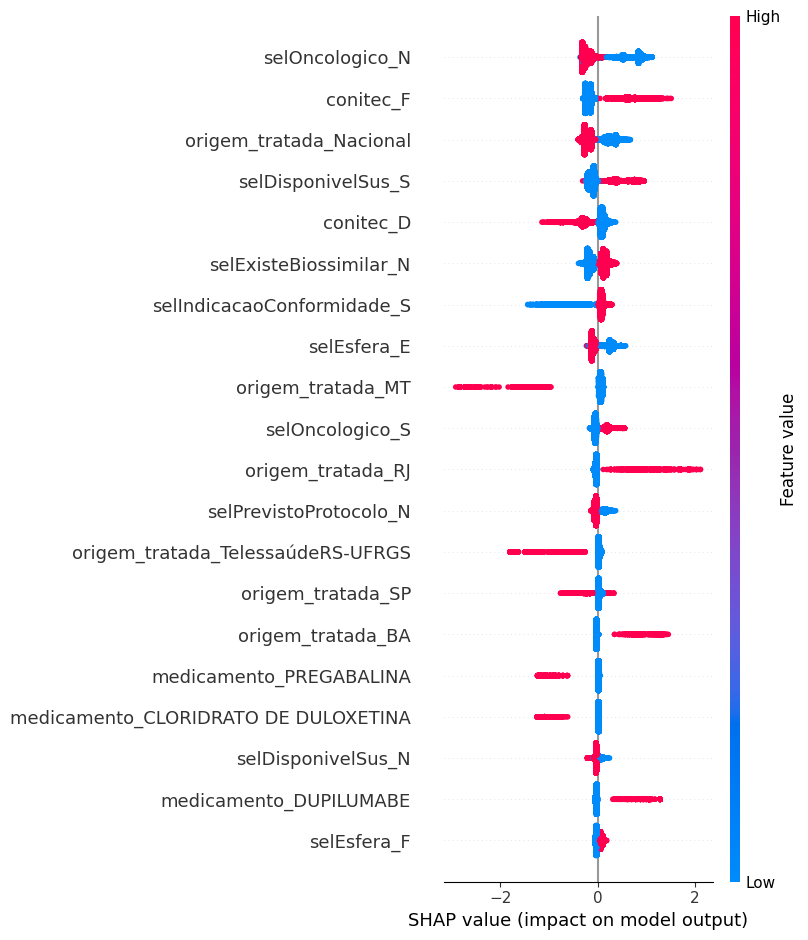

In [30]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_importance)

shap.summary_plot(shap_values, X_importance, feature_names)

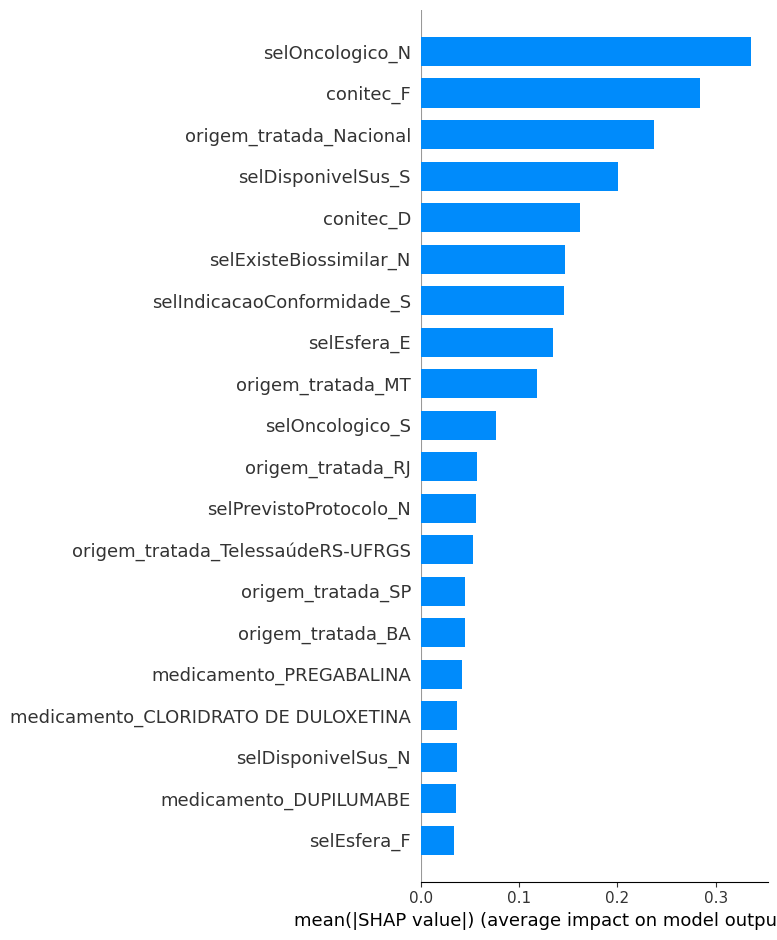

In [25]:
shap.summary_plot(shap_values, X_importance, feature_names, plot_type='bar')

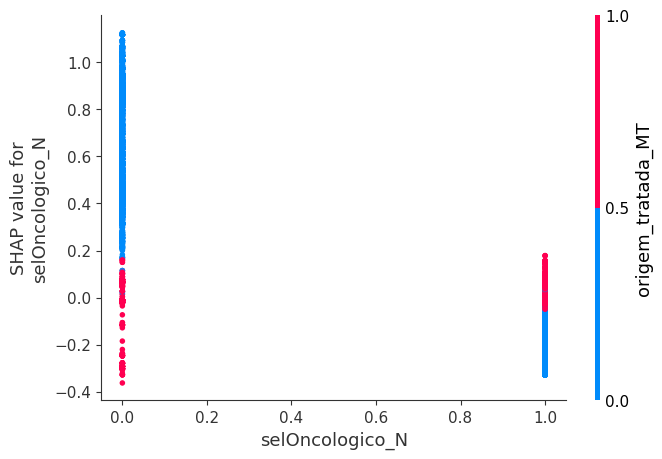

In [26]:
shap.dependence_plot("selOncologico_N", shap_values, X_importance, feature_names)

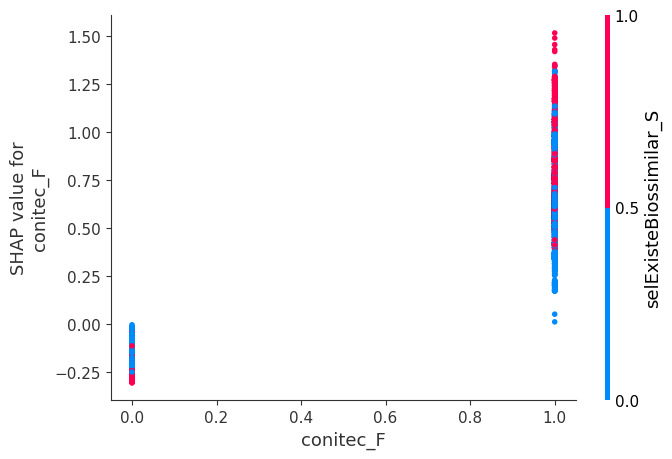

In [27]:
shap.dependence_plot("conitec_F", shap_values, X_importance, feature_names)

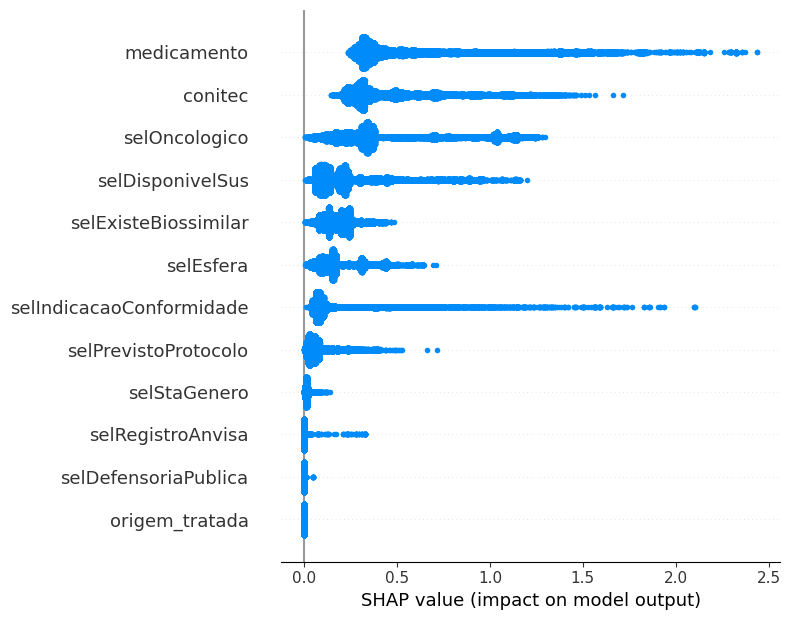

In [29]:
feature_to_original = [name.split("_")[0] for name in feature_names]
original_features = lista_X

shap_grouped = np.zeros((shap_values.shape[0], len(original_features)))

for i, orig in enumerate(original_features):
    idxs = [j for j, feat in enumerate(feature_to_original) if feat == orig]
    shap_grouped[:, i] = np.abs(shap_values[:, idxs]).sum(axis=1)


shap.summary_plot(shap_grouped, feature_names=original_features)

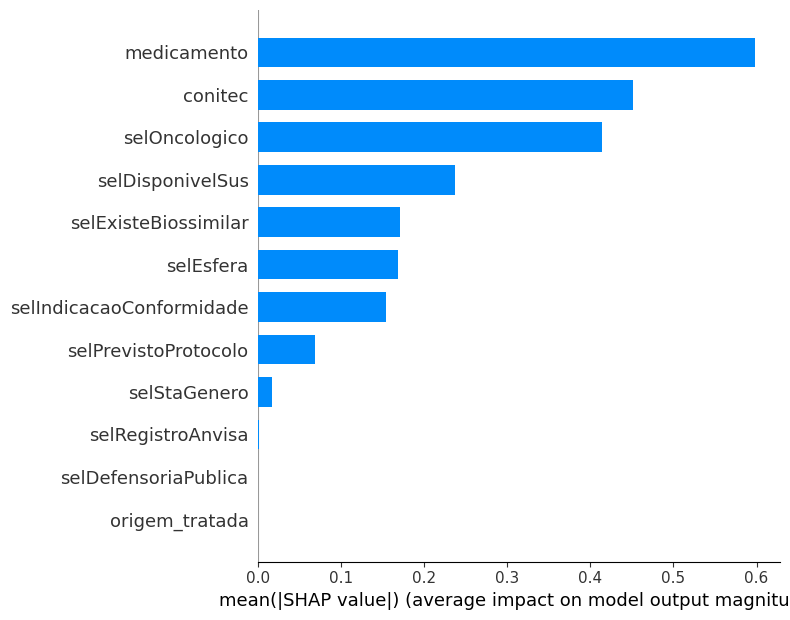

In [31]:
shap.summary_plot(shap_grouped, feature_names=original_features, plot_type='bar')

In [ ]:
amostra_fn

,medicamento,origem_tratada,selDefensoriaPublica,selStaGenero,selEsfera,selIndicacaoConformidade,selPrevistoProtocolo,selRegistroAnvisa,selDisponivelSus,selOncologico,selExisteBiossimilar,conitec,y,y_pred
129699,cesteamine,Nacional,D,m,F,N,N,N,N,N,N,Sem informação,1,0
143145,TETRAIDROCANABINOL + CANABIDIOL,Nacional,NÃO_PREENCHIDO,m,F,N,N,N,N,N,N,Sem informação,1,0
78947,ENOXAPARINA SÓDICA,Nacional,NÃO_PREENCHIDO,f,E,S,N,S,S,N,S,Sem informação,1,0
111375,CILOSTAZOL,RS/DMJ,D,m,E,S,N,S,N,N,S,Sem informação,1,0
100757,DENOSUMABE,RS/DMJ,D,m,E,S,N,S,N,N,N,D,1,0
40819,DAPAGLIFLOZINA,Nacional,NÃO_PREENCHIDO,m,E,S,N,S,S,N,S,F,1,0
119817,RISPERIDONA,Nacional,D,f,E,S,N,S,S,N,S,Sem informação,1,0
151824,NIVOLUMABE,Nacional,D,m,E,S,N,S,N,S,N,Sem informação,1,0
50016,OLANZAPINA,Nacional,NÃO_PREENCHIDO,m,F,N,N,S,S,N,S,Sem informação,1,0
48888,TOPIRAMATO,Nacional,D,m,E,S,N,S,N,N,N,Sem informação,1,0


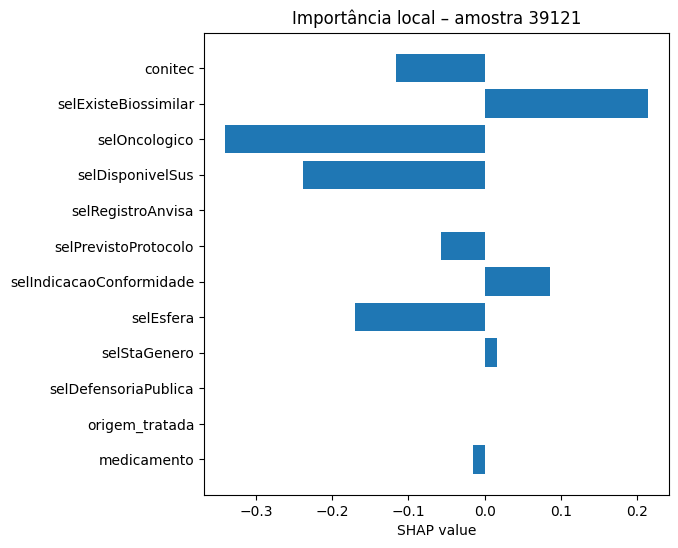

In [95]:
codigo = 48888
indice_no_Xtest = X_test.index.get_loc(codigo)
i = indice_no_Xtest


shap_row = shap_values[i]

feature_to_original = [name.split("_")[0] for name in feature_names]
original_features = lista_X

shap_row_grouped = {}
for orig in original_features:
    idxs = [j for j, feat in enumerate(feature_to_original) if feat == orig]
    shap_row_grouped[orig] = np.sum(shap_row[idxs])

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.barh(list(shap_row_grouped.keys()), list(shap_row_grouped.values()))
plt.xlabel("SHAP value")
plt.title(f"Importância local – amostra {i}")
plt.show()


In [97]:
df.columns

Index(['medicamento', 'cid', 'origem_tratada', 'selDefensoriaPublica',
       'selStaGenero', 'selEsfera', 'selIndicacaoConformidade',
       'selPrevistoProtocolo', 'selRegistroAnvisa', 'selDisponivelSus',
       'selOncologico', 'selExisteBiossimilar', 'conitec', 'y'],
      dtype='object')